# ELU Initialization in an RSL-RL-Style MLP

We compare two initializations in the common RSL-RL actor MLP

$$10 \;\to\; 256 \;\to\; 256 \;\to\; 256 \;\to\; 12$$

with an ELU after each hidden layer.

- **RSL-RL default** — PyTorch `nn.Linear` (Kaiming-uniform, `a=sqrt(5)`), i.e. $W\sim U\!\left(-\tfrac{1}{\sqrt{\mathrm{fan\_in}}},\ \tfrac{1}{\sqrt{\mathrm{fan\_in}}}\right)$, so $\operatorname{Var}(W)=\dfrac{1}{3\,\mathrm{fan\_in}}$.
- **ELU variance-preserving** — weight std scaled by a gain $g$ so each linear+ELU block roughly **preserves the activation second moment**.

Everything runs on the GPU; tensors move to CPU only to build the plots.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:   ", torch.cuda.get_device_name(0))


Device: cuda
GPU:    NVIDIA GeForce RTX 5090 Laptop GPU


## Estimate the ELU gain

ELU contracts the second moment: for $Z\sim\mathcal N(0,1)$,
$$q_{\mathrm{ELU}}=\mathbb E\!\left[\operatorname{ELU}(Z)^2\right]\approx 0.645 < 1,
\qquad g=\frac{1}{\sqrt{q_{\mathrm{ELU}}}}\approx 1.25,
\qquad g^2q_{\mathrm{ELU}}=1.$$

When the current pre-activation is still approximately $Z\sim\mathcal N(0,1)$, mean-field propagation gives
$$\mathbb E[z_{\mathrm{next}}^2]
\approx g^2\mathbb E\!\left[\operatorname{ELU}(Z)^2\right]
=1.$$
Thus unit pre-activation scale is a **local fixed point**; this does not say that the ELU output itself has unit variance.

Giving a hidden layer weight std $g/\sqrt{\mathrm{fan\_in}}$ cancels this contraction, so the
pre-activation second moment stays near $1$ layer after layer. The **first** layer keeps gain $1$
because its input is the raw observation (already $\approx\mathcal N(0,1)$), not a post-ELU signal.

Because ELU is **not positively homogeneous**, $q_{\mathrm{ELU}}$ only holds for a standard-Gaussian input, so
this is a *local* fix — good near $\mathcal N(0,1)$, not an exact scale invariance.

In [2]:
@torch.no_grad()
def estimate_elu_gain(num_samples=10_000_000):
    z = torch.randn(num_samples, device=device)          # sample on GPU
    q = F.elu(z).square().mean()
    return q.item(), q.rsqrt().item()                    # g = 1/sqrt(q), on GPU


q_elu, elu_gain = estimate_elu_gain()
print(f"q_ELU     = {q_elu:.6f}")
print(f"ELU gain  = {elu_gain:.6f}")
print(f"Var(W): ELU var-preserving = {elu_gain**2:.4f}/fan_in   vs   RSL-RL default = {1/3:.4f}/fan_in")


q_ELU     = 0.645034
ELU gain  = 1.245113
Var(W): ELU var-preserving = 1.5503/fan_in   vs   RSL-RL default = 0.3333/fan_in


The same gain can be tested around its calibration point with a mean-field Monte Carlo estimate. With $\operatorname{Var}(W)=g^2/\mathrm{fan\_in}$, the reported ratio is
$$\frac{\mathbb E[z_{\mathrm{next}}^2]}{\mathbb E[z^2]}
=\frac{g^2\mathbb E[\operatorname{ELU}(z)^2]}{\mathbb E[z^2]}.$$

In [3]:
locality_specs = [("N(0, 1)", 0.0, 1.0),
                  ("N(0, 2^2)", 0.0, 2.0),
                  ("N(0, 0.5^2)", 0.0, 0.5),
                  ("N(1, 1)", 1.0, 1.0)]
locality_rng = torch.Generator(device=device).manual_seed(1)
header = f"{'input distribution':<20} | {'input mean':>10} | {'input std':>9} | {'preservation ratio':>18}"
print(header)
print("-" * len(header))

for label, input_mean, input_std in locality_specs:
    z = input_mean + input_std * torch.randn(2_000_000, device=device, generator=locality_rng)
    a = F.elu(z)
    ratio = elu_gain**2 * a.square().mean() / z.square().mean()
    print(f"{label:<20} | {z.mean().item():>10.4f} | {z.std(unbiased=False).item():>9.4f} | {ratio.item():>18.4f}")


input distribution   | input mean | input std | preservation ratio
------------------------------------------------------------------
N(0, 1)              |     0.0001 |    1.0000 |             1.0004
N(0, 2^2)            |    -0.0002 |    2.0007 |             0.8755
N(0, 0.5^2)          |    -0.0000 |    0.4999 |             1.1615
N(1, 1)              |     0.9996 |    1.0001 |             1.5138


The near-unit ratio is local to the zero-mean, unit-Gaussian pre-activation; changing its scale or mean moves the ratio away from $1$.

In [4]:
class RSLStyleMLP(nn.Module):
    def __init__(self, input_dim=10, hidden_dims=(256, 256, 256), output_dim=12):
        super().__init__()

        dims = [input_dim, *hidden_dims, output_dim]
        layers = []

        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))

            if i < len(dims) - 2:
                layers.append(nn.ELU())

        self.net = nn.Sequential(*layers)

    def forward_with_activations(self, x):
        values = {"input": x}
        h = x
        hidden_id = 0

        for layer in self.net:
            h = layer(h)

            if isinstance(layer, nn.ELU):
                hidden_id += 1
                values[f"hidden_{hidden_id}"] = h

        values["output"] = h
        return values


@torch.no_grad()
def init_elu_aware(model, gain):
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    for i, layer in enumerate(linear_layers):
        current_gain = 1.0 if i == 0 else gain          # first layer sees raw ~N(0,1) input
        std = current_gain / math.sqrt(layer.in_features)

        nn.init.normal_(layer.weight, mean=0.0, std=std)
        nn.init.zeros_(layer.bias)


## Forward-propagate the same input through both networks

We report `std` and the second moment `E[x^2]` separately: ELU has a **nonzero mean**, so after an
ELU $\operatorname{Var}=\mathbb E[x^2]-\mathbb E[x]^2$ and hence $\operatorname{std}<\sqrt{\mathbb E[x^2]}$.

In [5]:
batch_size = 10_000
x = torch.randn(batch_size, 10, device=device)

torch.manual_seed(0)
default_model = RSLStyleMLP().to(device)                # RSL-RL default (nn.Linear) init

torch.manual_seed(0)
elu_model = RSLStyleMLP().to(device)
init_elu_aware(elu_model, elu_gain)                     # overwrite with ELU variance-preserving init

with torch.no_grad():                                   # inference only, no autograd graph
    default_values = default_model.forward_with_activations(x)
    elu_values = elu_model.forward_with_activations(x)


def print_stats(title, values):
    print(f"\n{title}")
    print(f"{'layer':<12}{'mean':>12}{'std':>12}{'E[x^2]':>12}")

    for name, tensor in values.items():
        print(
            f"{name:<12}"
            f"{tensor.mean().item():>12.4f}"
            f"{tensor.std(unbiased=False).item():>12.4f}"
            f"{tensor.square().mean().item():>12.4f}"
        )


print_stats("RSL-RL default", default_values)
print_stats("ELU variance-preserving", elu_values)



RSL-RL default
layer               mean         std      E[x^2]
input             0.0043      0.9998      0.9997
hidden_1          0.0651      0.5065      0.2608
hidden_2          0.0177      0.2707      0.0736
hidden_3          0.0069      0.1504      0.0227
output           -0.0179      0.0916      0.0087

ELU variance-preserving
layer               mean         std      E[x^2]
input             0.0043      0.9998      0.9997
hidden_1          0.1528      0.7734      0.6215
hidden_2          0.1663      0.7772      0.6317
hidden_3          0.1404      0.7592      0.5962
output            0.0300      0.8502      0.7238


## The headline: scale vs depth

One picture for the whole story — the RSL-RL default shrinks the activation scale at every layer,
while the ELU variance-preserving init holds it roughly constant.

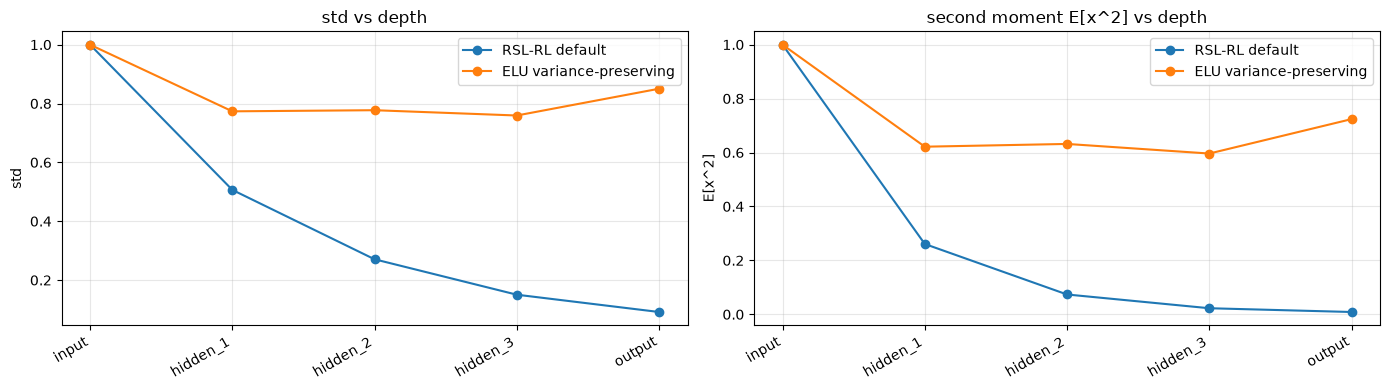

In [6]:
SERIES = [("RSL-RL default",          default_values, "C0"),
          ("ELU variance-preserving", elu_values,     "C1")]
layer_names = list(default_values.keys())
xs = np.arange(len(layer_names))

def curve(values, reduce_fn):
    return [reduce_fn(values[n]).item() for n in layer_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, values, c in SERIES:
    axes[0].plot(xs, curve(values, lambda t: t.std(unbiased=False)),  "o-", color=c, label=label)
    axes[1].plot(xs, curve(values, lambda t: t.square().mean()),      "o-", color=c, label=label)

for ax, title, ylab in [(axes[0], "std vs depth", "std"),
                        (axes[1], "second moment E[x^2] vs depth", "E[x^2]")]:
    ax.set_xticks(xs); ax.set_xticklabels(layer_names, rotation=30, ha="right")
    ax.set_title(title); ax.set_ylabel(ylab); ax.grid(alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


## Per-layer activation distributions

Same information, distribution by distribution. The default (blue) collapses into a narrow spike at
$0$; the ELU variance-preserving init (orange) keeps a stable spread. Tensors go to CPU only here, for plotting.

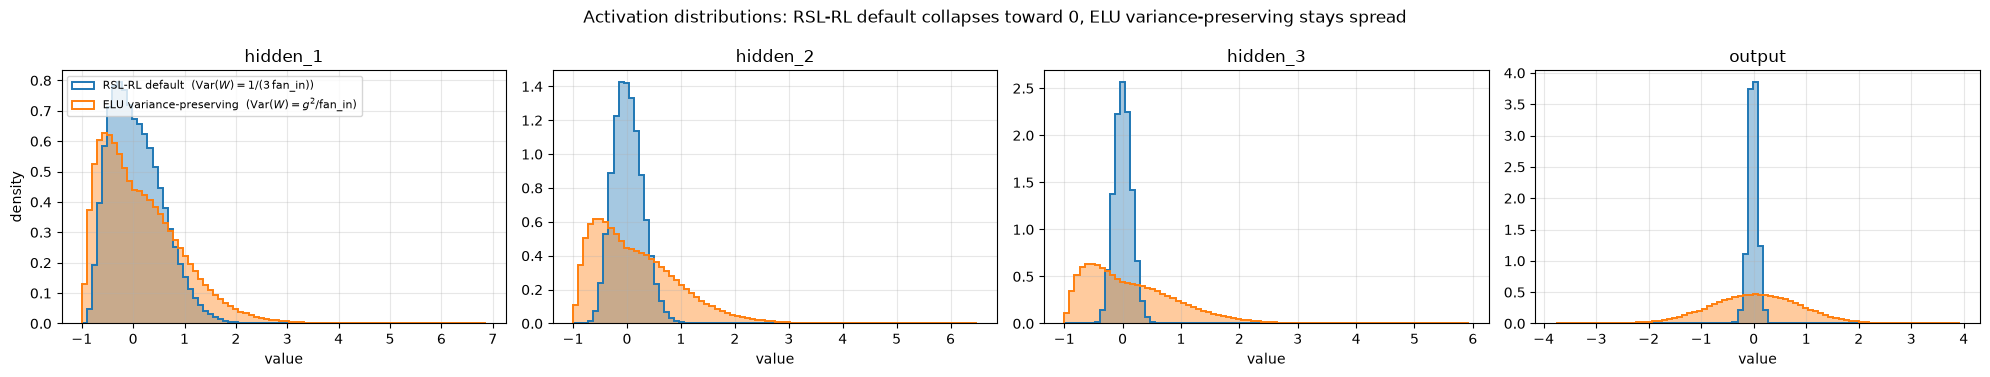

In [7]:
plot_layers = ["hidden_1", "hidden_2", "hidden_3", "output"]
legend = {"RSL-RL default":          r"RSL-RL default  ($\mathrm{Var}(W)=1/(3\,\mathrm{fan\_in})$)",
          "ELU variance-preserving": r"ELU variance-preserving  ($\mathrm{Var}(W)=g^2/\mathrm{fan\_in}$)"}

fig, axes = plt.subplots(1, len(plot_layers), figsize=(20, 3.8))
for ax, name in zip(axes, plot_layers):
    cpu_data = {label: values[name].detach().reshape(-1).cpu().numpy()
                for label, values, _ in SERIES}                 # -> CPU only for matplotlib
    lo = min(data.min() for data in cpu_data.values())
    hi = max(data.max() for data in cpu_data.values())
    shared_bins = np.linspace(lo, hi, 81)

    for label, _, c in SERIES:
        data = cpu_data[label]
        ax.hist(data, bins=shared_bins, density=True, histtype="stepfilled",
                alpha=0.4, color=c)
        ax.hist(data, bins=shared_bins, density=True, histtype="step",
                linewidth=1.4, color=c, label=legend[label])
    ax.set_title(name); ax.set_xlabel("value"); ax.grid(alpha=0.3)

axes[0].set_ylabel("density")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Activation distributions: RSL-RL default collapses toward 0, ELU variance-preserving stays spread")
plt.tight_layout(); plt.show()


## Conclusion

The RSL-RL default initialization usually makes the ELU activations smaller after each layer.

The ELU variance-preserving initialization usually keeps their scale more stable.

This only tests forward propagation.

PyTorch's default `nn.Linear` has $\operatorname{Var}(W)=1/(3\,\mathrm{fan\_in})$, so it tends to shrink scale layer by layer; a complete block does not simply multiply the second moment by $1/3$ because ELU, bias, and the evolving distribution also matter. For the three-hidden-layer MLP common in RSL-RL, this is visible but is not evidence of a faulty initialization: the network is shallow, ELU is nearly linear with derivative near $1$ around zero, and well-scaled observations plus Adam can tolerate moderate contraction. A steadier forward scale does not establish a better PPO return, and this notebook also changes the first-layer and output-head scales, so it does not isolate the ELU gain. Treat the RSL-RL default as the baseline; a fair test applies ELU-aware initialization only to hidden layers while holding the actor mean head, critic output head, and action-noise parameters fixed, then compares learning stability and return across multiple seeds.

Also it seems very hard to tune every layer to be exact gaussian, so batch normalization make sense in large nn with multiple hidden layer

Torch default initialization seems to be better